In [2]:
import pandas as pd

df = pd.read_csv('data.csv') # 주택 가격 데이터 불러오기
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info() # 결측치, 자료형 등 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
print(0.0 in df['price']) # 주택 가격이 0인 경우가 있음

True


In [5]:
df[df['price']==0].head() # 유효한 데이터임에도 불구하고 주택 가격이 0인 경우가 존재 # 0이 특별한 의미가 있나?
                          # 주택 가격 0에 대한 예측도 모델에 적용시켜 버리면 성능 측면에서 악영향이 나타날 수 있다
                          # 물론 데이터의 유효성 측면에서는 데이터를 임의로 삭제하는 것에 주의가 필요하지만,
                          # 이 실습에서는 주택 가격이 0인 경우를 실제 주택 가격을 나타내지 않는 비정상적인 데이터로 분류하여
df = df[df['price'] > 0]  # 주택 가격이 0인 행은 삭제하는 방식이 적절하다고 판단하였다

In [6]:
X = df.iloc[:, 2:13] # bedrooms ~ yr_built
# 침실, 화장실, 주거 면적, 토지 면적, 층수, 해안가 유무, view 평점, 상태 평점, 지상층 면적, 지하층 면적, 지어진 연도
# 보수 연도는 0값도 포함하고 있으며, 이를 이상치로 판단할 경우 모델에 직접 넣기에는 적합하지 않을 수도 있다
y = df['price'] # 주택 가격을 종속변수로

In [7]:
from sklearn.model_selection import train_test_split # train, test 데이터를 나누기 위한 모듈

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42) # 전체 데이터 중 test데이터를 약 30%로 설정
                                                                                         # 42는 엄청난 수 라네요

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # 모델 생성
model.fit(X_train, y_train) # train 데이터로 학습

LinearRegression()

In [9]:
predictions = model.predict(X_test)
predictions_r = list(map(lambda x : round(float(x)), model.predict(X_test)))
print("예측값:", predictions_r[:5])
print("실제값:", y_test.iloc[:5].values)

예측값: [1371862, 612036, 658807, 277695, 522069]
실제값: [1225000.  496752.  612500.  265000.  615000.]


In [10]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.1874943759943256
0.5847075287616623


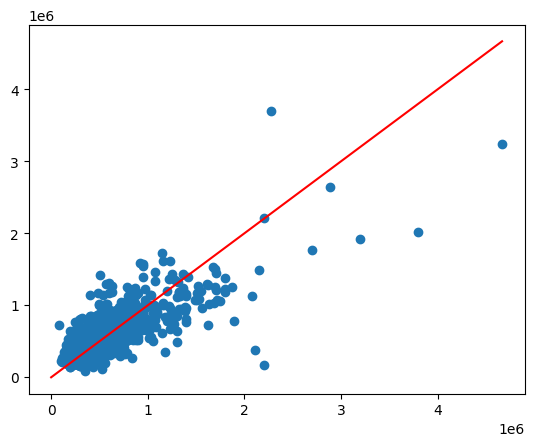

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

mx = int(max(y_test.max(), predictions.max()))

plt.scatter(y_test, predictions)
plt.plot([0, mx], [0, mx], color='red') # 기울기가 1인 그래
plt.show()